In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import regionmask as regmask
import matplotlib.pyplot as plt
import xclimate as xclim

In [3]:
ROOTDIR = Path("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/nhd")

# tmax_fhist = xr.open_dataset(ROOTDIR / "TREFMXAV_daily_stats_199501-201412.nc")
# tmax_goga = xr.open_dataset(ROOTDIR / "GOGA2_TREFMXAV_R_daily_stats_199501-201412.nc")
# tmax_goga = xr.open_dataset(ROOTDIR / "GOGA2_TREFMXAV_R_daily_stats_199501-201412.nc")

thresh_fhist = xr.open_dataset(ROOTDIR / "FHIST_TREFMXAV_JJA_daily_199501-201412_nhd_thresholds.nc")
nhd_fhist = xr.open_dataset(ROOTDIR / "FHIST_TREFMXAV_JJA_daily_199501-201412_nhd.nc", decode_timedelta=False)

thresh_goga = xr.open_dataset(ROOTDIR / "GOGA2_TREFMXAV_JJA_daily_199501-201412_nhd_thresholds.nc")
nhd_goga = xr.open_dataset(ROOTDIR / "GOGA2_TREFMXAV_JJA_daily_199501-201412_nhd.nc", decode_timedelta=False)

In [4]:
gc = dict(lat=45, lon=260, method='nearest')

In [5]:
thresh_fhist.thresholds

<xarray.DataArray 'thresholds' (quantile: 3, member: 27, dayofyear: 366,
                                lat: 96, lon: 144)> Size: 3GB
[409826304 values with dtype=float64]
Coordinates:
  * quantile   (quantile) float64 24B 0.9 0.95 0.99
  * member     (member) int64 216B 0 1 2 3 4 5 6 7 8 ... 20 21 22 23 24 25 26 27
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * lat        (lat) float32 384B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    ltype      int64 8B ...
    landunit   <U40 160B ...
Attributes:
    units:        K
    long_name:    Climatological percentile threshold
    window_days:  5
    description:  Per-DOY, per-member temperature percentile thresholds from ...

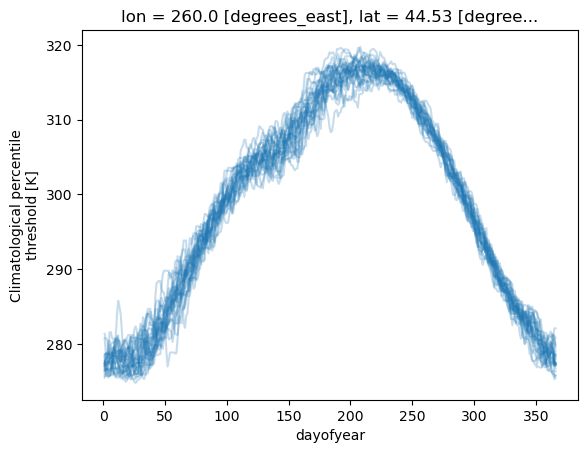

In [7]:
for m in thresh_fhist.member:
    thresh_fhist.thresholds.sel(**gc, quantile=0.95, member=m).plot(c='tab:blue', alpha=0.25)

In [10]:
GRIDCELLS = {
    "ngp": dict(lon=263, lat=50, method="nearest"),
    "eus": dict(lon=280, lat=39, method="nearest"),
    "amz": dict(lon=295, lat=0, method="nearest"),
    "nru": dict(lon=120, lat=63, method="nearest"),
    "ukr": dict(lon=42, lat=50, method="nearest"),
    "cng": dict(lon=22, lat=0, method="nearest"),
    "gui": dict(lon=140, lat=-5, method="nearest"),
    "aus": dict(lon=137, lat=-22, method="nearest"),
}

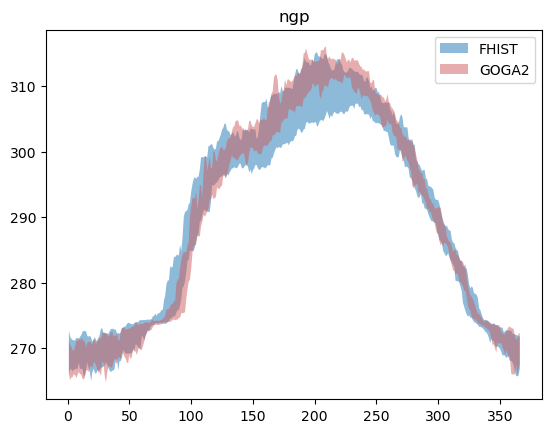

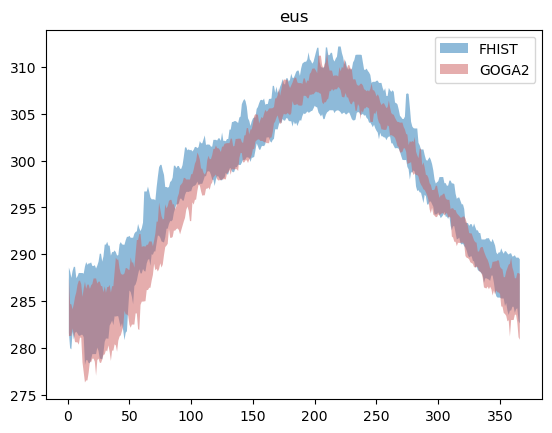

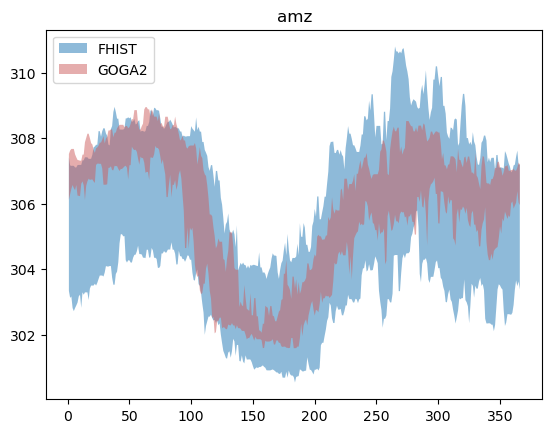

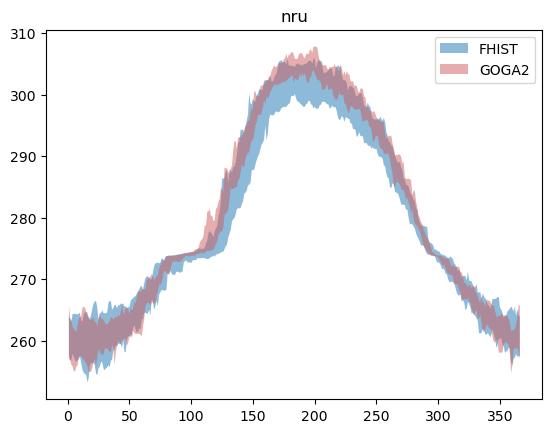

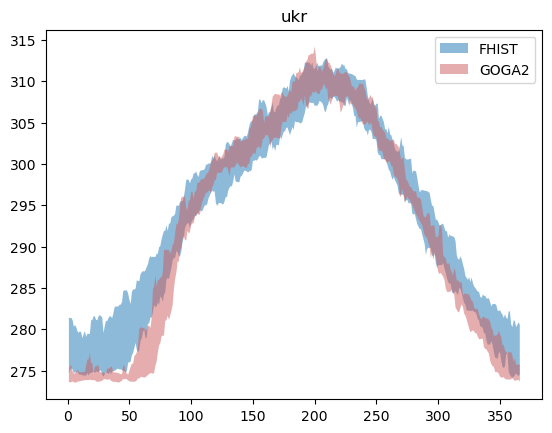

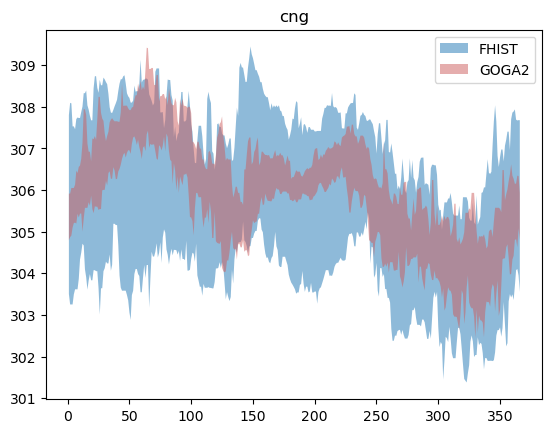

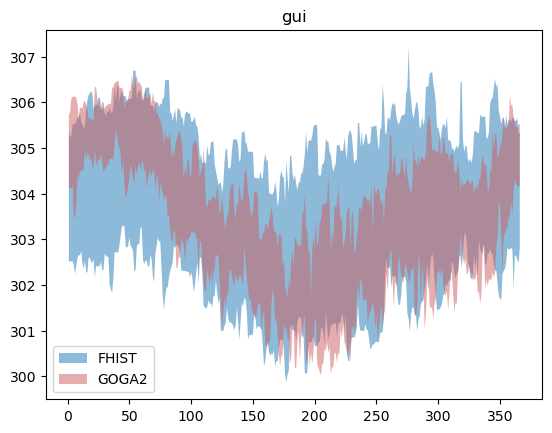

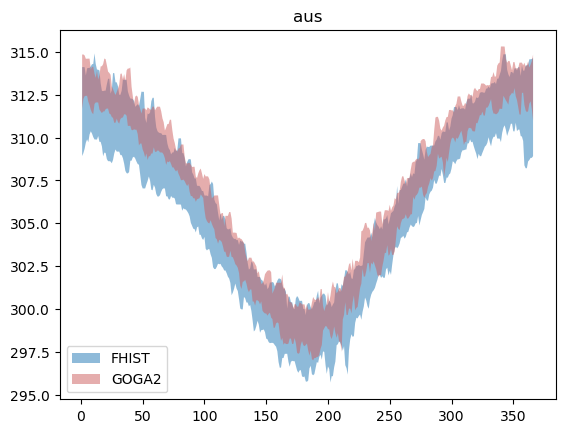

In [15]:
for gc_name, gc_dict in GRIDCELLS.items():
    fig = plt.figure()
    plt.fill_between(
        thresh_fhist.dayofyear,
        thresh_fhist.thresholds.sel(quantile=0.95, **gc_dict).min(dim="member"),
        thresh_fhist.thresholds.sel(quantile=0.95, **gc_dict).max(dim="member"),
        alpha=0.5,
        facecolor="tab:blue",
        label="FHIST"
    )
    plt.fill_between(
        thresh_goga.dayofyear,
        thresh_goga.thresholds.sel(quantile=0.95, **gc_dict).min(dim="member"),
        thresh_goga.thresholds.sel(quantile=0.95, **gc_dict).max(dim="member"),
        alpha=0.5,
        facecolor="indianred",
        label="GOGA2"
    )
    plt.legend()
    plt.title(gc_name)

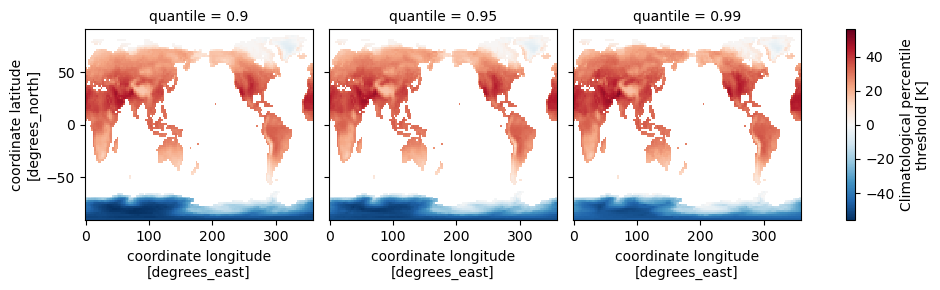

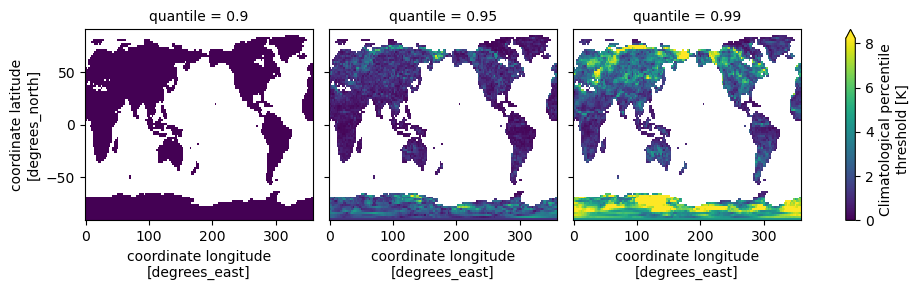

In [30]:
(thresh_fhist.thresholds.sel(dayofyear=180, member=0) - 273.15).plot(col='quantile')
(thresh_fhist.thresholds.sel(dayofyear=180, member=0) - thresh_fhist.thresholds.sel(quantile=0.90, dayofyear=180, member=0)).plot(col='quantile', robust=True)

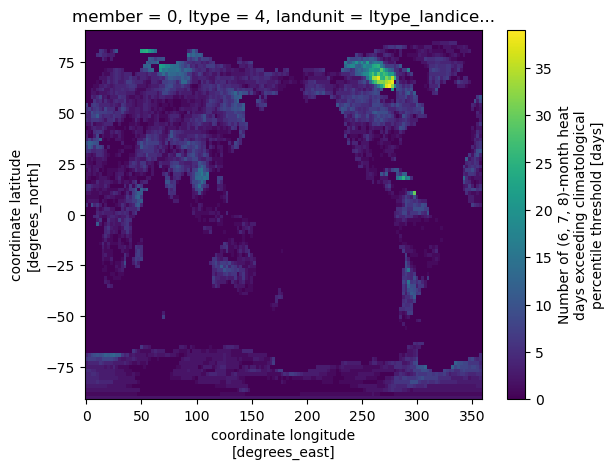

In [21]:
nhd_fhist.nhd.sel(quantile=0.95, member=0, year=1995).plot()

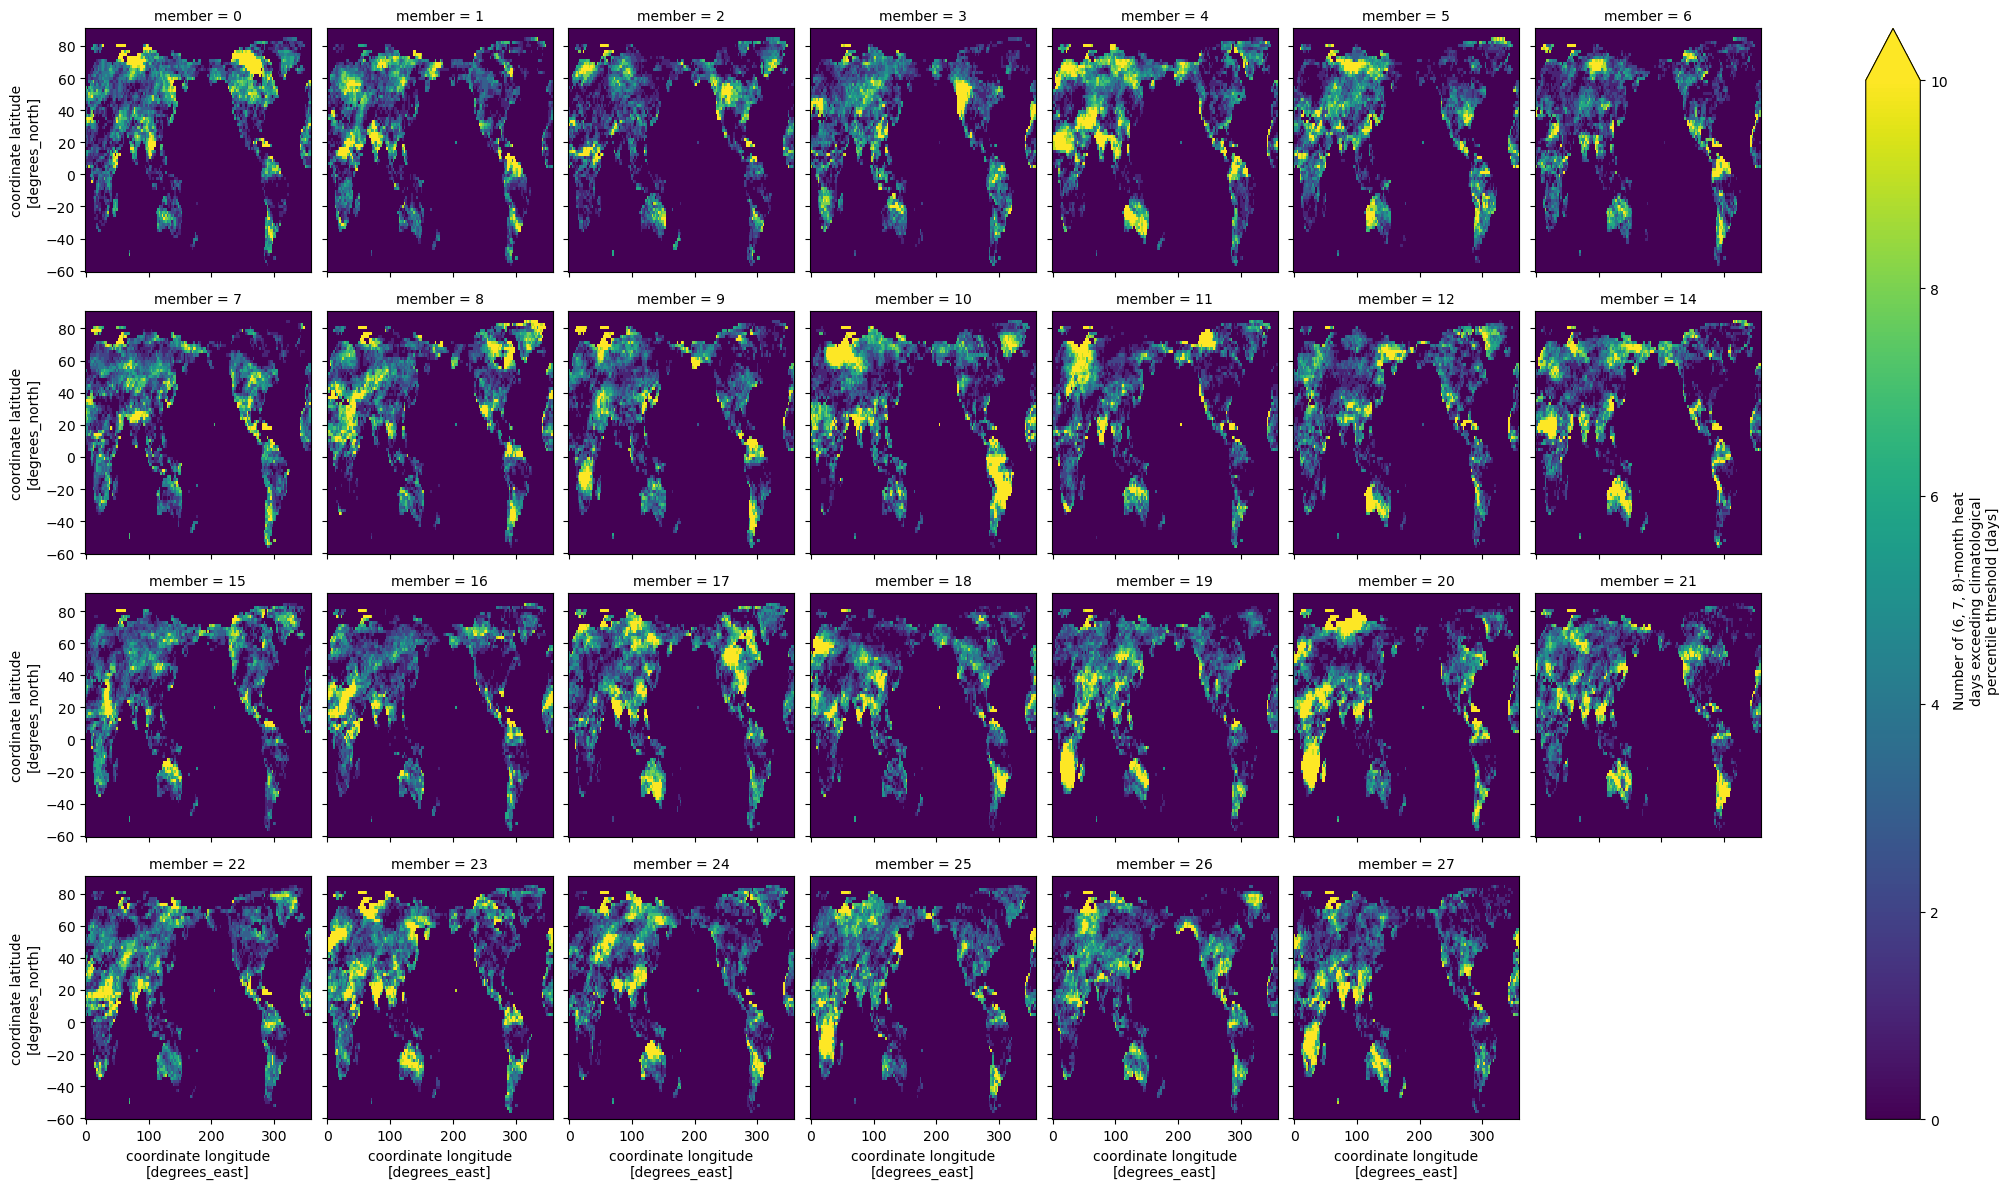

In [25]:
nhd_fhist.nhd.sel(quantile=0.95, year=1995, lat=slice(-60, None)).plot(col='member', col_wrap=7, robust=True)

In [32]:
# nhd_fhist.nhd.sel(quantile=0.95, lat=slice(-60, None)).sum(dim='year').plot(col='member', col_wrap=7, robust=True)

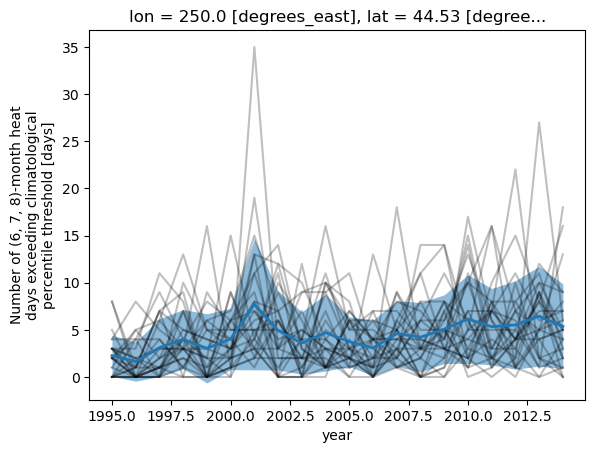

In [47]:
gc = dict(lat=45, lon=250, method='nearest')

for i in range(27):
    nhd_fhist.nhd.isel(member=i).sel(quantile=0.95, **gc).plot(color='k', alpha=0.25)

nhd_fhist.nhd.sel(quantile=0.95, **gc).mean(dim='member').plot(color='tab:blue', lw=2)
plt.fill_between(
    nhd_fhist.year,
    nhd_fhist.nhd.sel(quantile=0.95, **gc).mean(dim='member') - nhd_fhist.nhd.sel(quantile=0.95, **gc).std(dim='member'),
    nhd_fhist.nhd.sel(quantile=0.95, **gc).mean(dim='member') + nhd_fhist.nhd.sel(quantile=0.95, **gc).std(dim='member'),
    color='tab:blue',
    alpha=0.5,
    lw=0,
)

In [36]:
nhd_fhist

<xarray.Dataset> Size: 179MB
Dimensions:   (member: 27, quantile: 3, year: 20, lat: 96, lon: 144)
Coordinates:
  * member    (member) int64 216B 0 1 2 3 4 5 6 7 8 ... 20 21 22 23 24 25 26 27
  * quantile  (quantile) float64 24B 0.9 0.95 0.99
  * year      (year) int64 160B 1995 1996 1997 1998 1999 ... 2011 2012 2013 2014
  * lat       (lat) float32 384B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon       (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    ltype     int64 8B ...
    landunit  <U40 160B ...
Data variables:
    nhd       (member, quantile, year, lat, lon) int64 179MB ...
Attributes:
    description:  (6, 7, 8) months heat-day counts
    nhd_method:   Raw temperature; per-member 5-day centered DOY-window perce...
    percentiles:  [0.9  0.95 0.99]
    window_days:  5
    dataset:      fhist